# Stack Overflow Developer Survey Analysis  
## IBM Data Analyst Capstone Project

In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/01_data_collection_cleaned_survey.csv")

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,"Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time",Experience_Level,Experience_group,Employment_group,comp_upper_threshold,comp_lower_threshold
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary,Books / Physical media,NaN,...,0,0,0,0,0,Mid,6-10,Full-time,409238.403075,-264085.686508
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor's degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0,0,0,0,0,Senior,11-20,Full-time,409238.403075,-264085.686508
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master's degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0,0,0,0,0,Expert,20+,Full-time,409238.403075,-264085.686508
3,4,I am learning to code,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Unknown,Some college,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,0,0,0,1,0,Mid,6-10,Student,409238.403075,-264085.686508
4,5,I am a developer by profession,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Unknown,Secondary,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,0,0,0,1,0,Mid,6-10,Student,409238.403075,-264085.686508


--------------------
### DATA VISUALIZATION
##### Creating a SQLite Database and Inserting the Data
--------------------

In [2]:
import sqlite3

conn = sqlite3.connect("../data/survey-data.sqlite")
df.to_sql("main", conn, if_exists="replace", index=False)
conn.close()

In [3]:
conn = sqlite3.connect("../data/survey-data.sqlite")

QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment                            RemoteWork   Check  \
0  Employed, full-time                                Remote  Apples   
1  Employed, full-time                                Remote  Apples   
2  Employed, full-time                                Remote  Apples   
3   Student, full-time  Hybrid (some remote, some in-person)  Apples   
4   Student, full-time  Hybrid (some remote, some in-person)  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source proje

#### 📌 Running SQL Queries

In [4]:
# Number of rows in the table 
QUERY = """
SELECT COUNT (*)
FROM main 
"""
df = pd.read_sql_query(QUERY, conn)
df.head()

,COUNT (*)
0,65437


In [5]:
# Names of all tables in the database
QUERY = """
SELECT name as Table_name FROM sqlite_master
WHERE type = "table"
"""
pd.read_sql_query(QUERY, conn)

,Table_name
0,main


In [6]:
# Grouping data by Age, to get the count of respondents in each age group:
QUERY = """
SELECT age , COUNT (*) as count
FROM main 
GROUP BY age
ORDER BY age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [7]:
# Schema of the main table:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master
WHERE name = '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])

CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" REAL,
  "YearsCodePro" REAL,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


 #### 📌 Visualizing the Distribution of Data

In [8]:
df = pd.read_csv("../data/01_data_collection_cleaned_survey.csv")
import seaborn as sns
import matplotlib.pyplot as plt

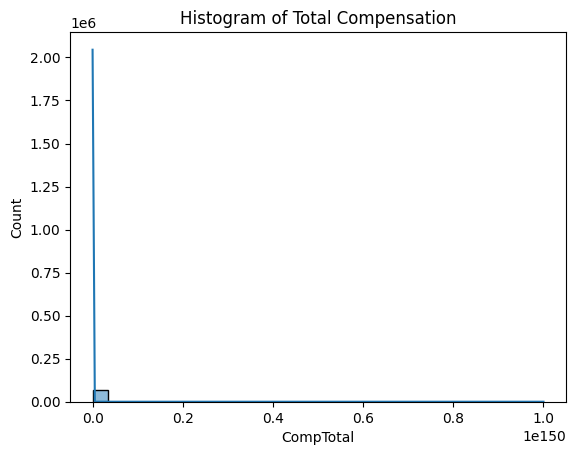

In [9]:
# Histogram of Total Compensation
sns.histplot(df["CompTotal"], bins = 30, kde = True)
plt.title("Histogram of Total Compensation")
plt.show()

In [10]:
# Age Distribution

df["Age"].value_counts()

age_map = {
    "Under 18": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 70
}

df["Age_numeric"] = df["Age"].map(age_map)

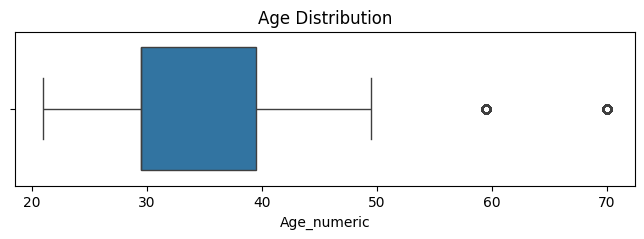

In [11]:

plt.figure(figsize=(8, 2))

sns.boxplot(x=df["Age_numeric"])
plt.title("Age Distribution")

plt.show()

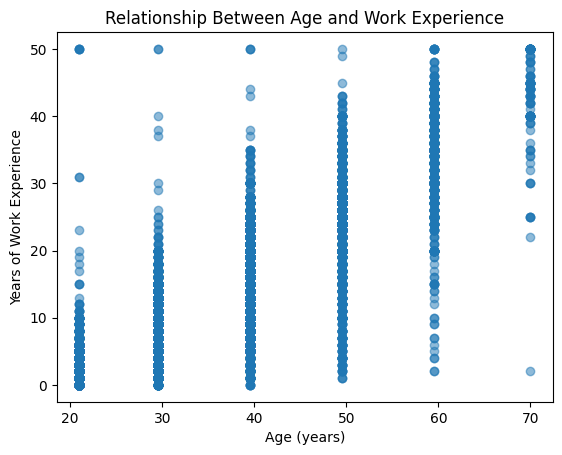

In [17]:
# Scatter plot of Age and Work Experience

import matplotlib.pyplot as plt

age_map = {
    "Under 18": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 70
}

df["Age_numeric"] = df["Age"].map(age_map)


plt.scatter(df["Age_numeric"], df["WorkExp"], alpha=0.5)

plt.title("Relationship Between Age and Work Experience")
plt.xlabel("Age (years)")
plt.ylabel("Years of Work Experience")
plt.show()

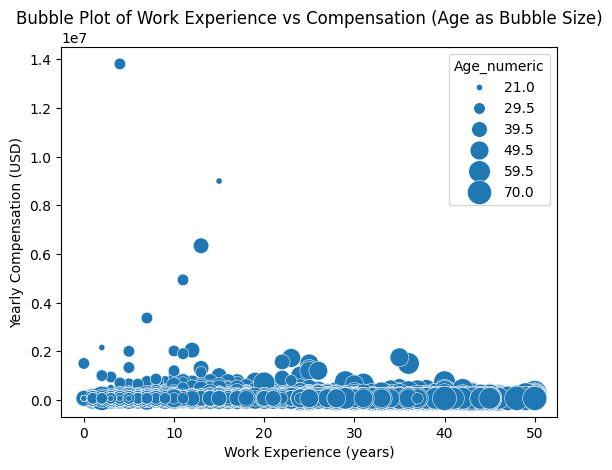

In [19]:
# Bubble plot of TimeSearching and Frustration using the Age column as the bubble size.

sns.scatterplot(
    data=df.dropna(subset=["WorkExp", "ConvertedCompYearly", "Age_numeric"]),
    x="WorkExp",
    y="ConvertedCompYearly",
    size="Age_numeric",
    sizes=(20, 300)
)

plt.title("Bubble Plot of Work Experience vs Compensation (Age as Bubble Size)")
plt.xlabel("Work Experience (years)")
plt.ylabel("Yearly Compensation (USD)")
plt.show()

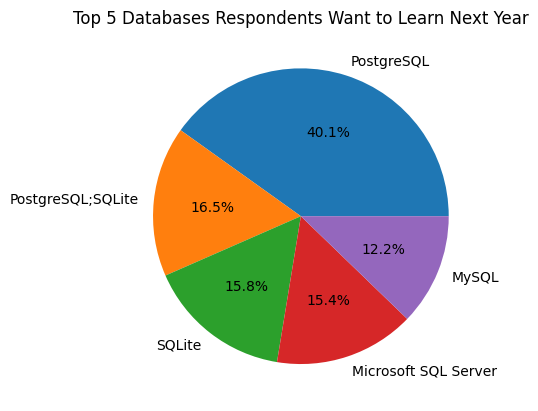

In [27]:
# Pie chart of the top 5 databases(DatabaseWantToWorkWith) that respondents wish to learn next year.

top5 = df["DatabaseWantToWorkWith"].value_counts().head(5)

plt.pie(
top5.values, 
labels=top5.index,
autopct="%1.1f%%")
plt.title("Top 5 Databases Respondents Want to Learn Next Year")
plt.show()

In [35]:
# stacked bar chart of median TimeSearching and TimeAnswering for the age group 30 to 35.

df_age_filtered = df[(df["Age_numeric"]>= 30) & (df["Age_numeric"]<= 35)]
df_age_filtered

median_timeSearching= df_age_filtered["TimeSearching"].median()
median_timeSearching


nan

In [29]:
#Line Chart
#Plot the median CompTotal for all ages from 45 to 60.

In [ ]:
#Bar Chart
#Create a horizontal bar chart using the MainBranch column.